### start

In [1]:
import sys
from path_config import *

import myfunction as mf
import myrfecv as mr
import mygeo as mg

import os
import random
import joblib
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy.stats import skew, kurtosis,yeojohnson, boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# 1小时后运行，time sleep
# import time
# time.sleep(3600)


### data prep

In [ ]:
import pandas as pd
from scipy.stats import boxcox

def process_pfas_data(path_part0_match, filename, path_file, selector, list_pfas, list_treat_value=['log', 'minmax']):
    """
    通用 PFAS 数据处理函数：Box-Cox + 归一化（MinMax 或 ZScore）

    参数：
        path_part0_match: 数据路径前缀
        filename: CSV 文件名
        path_file: mf.select_data 的文件路径参数
        selector: mf.select_data 的第二个参数 ('w' 或 'bio')
        list_pfas: 需要选择的 posname 列表
        list_treat_value: 处理方法 ['log', 'minmax'] 或 ['log', 'zscore']

    返回：
        df_train: 训练集数据（去掉指定列）
        df_transfer: transfer 数据（非 list_pfas 部分）
        list_inv_parm: 反处理参数 [min,max,lambda] 或 [mean,std,lambda]
    """

    df_raw = pd.read_csv(path_part0_match + filename)

    df_data_raw = mf.select_data(df_raw, path_file, selector)
    # Box-Cox 转换
    df_data_raw['value'], lam = boxcox(df_data_raw['value'])
    print(f'Box-Cox Lambda: {lam}')

    # 归一化方法选择
    if 'minmax' in list_treat_value:
        max_val = df_data_raw['value'].max()
        min_val = df_data_raw['value'].min()
        print(f"[MinMax] Max: {max_val}, Min: {min_val}")
        df_data_raw['value'] = (df_data_raw['value'] - min_val) / (max_val - min_val)
        list_inv_parm = [min_val, max_val, lam]

    elif 'zscore' in list_treat_value:
        mean_val = df_data_raw['value'].mean()
        std_val = df_data_raw['value'].std()
        print(f"[ZScore] Mean: {mean_val}, Std: {std_val}")
        df_data_raw['value'] = (df_data_raw['value'] - mean_val) / std_val
        list_inv_parm = [mean_val, std_val, lam]

    else:
        raise ValueError("list_treat_value 必须包含 'minmax' 或 'zscore'")

    # 分成训练和 transfer
    df_train = df_data_raw[df_data_raw['posname'].isin(list_pfas)]
    df_transfer = df_data_raw[~df_data_raw['posname'].isin(list_pfas)]

    columns_to_drop = ['lon_grid', 'lat_grid', 'posname']
    df_train = df_train.drop(columns=columns_to_drop)
    df_train['year'] = (df_train['year'] - 2000) / (2020 - 2000)
    print(df_train[['po_chain', 'pr', 'GDP', 'year','value']].head())
    print(df_train.shape)

    return df_train, list_inv_parm, df_transfer


In [7]:
int_rdm = 202509
str_describe_sw = 'sw'
str_describe_lr = 'lr'
save_file = True

list_pfas = ['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 
             'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 
             'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']

In [ ]:
# 处理 water 数据
list_treat_value = ['log', 'zscore']
df_sw_data, list_inv_param_sw, df_sw_transfer = process_pfas_data(
    path_part0_match=path_part0_match,
    filename="sw_match_geo_auto_zscore.csv",
    path_file=path_file,
    selector='w',
    list_pfas=list_pfas,
    list_treat_value=list_treat_value  # 或 ['log', 'zscore']
)
print(df_sw_data[['po_chain', 'log_Koc', 'pr', 'GDP', 'year','value']].head())

Box-Cox Lambda: 0.008311324185806193
[ZScore] Mean: -1.207537003304758, Std: 2.956489677281309
   po_chain        pr       GDP  year     value
0         0 -1.876353 -0.549876   0.7 -0.551984
1         1 -1.876353 -0.549876   0.7 -0.447474
2         0 -1.876353 -0.549876   0.7 -0.051806
3         0 -1.876353 -0.549876   0.7  0.299111
4         1 -1.876353 -0.549876   0.7 -0.172125
(13256, 43)
   po_chain   log_Koc        pr       GDP  year     value
0         0 -0.784157 -1.876353 -0.549876   0.7 -0.551984
1         1 -0.666881 -1.876353 -0.549876   0.7 -0.447474
2         0 -0.053628 -1.876353 -0.549876   0.7 -0.051806
3         0 -0.304311 -1.876353 -0.549876   0.7  0.299111
4         1 -0.021871 -1.876353 -0.549876   0.7 -0.172125


### water rfecv

XGBR Optimal number of features: 32
RF Optimal number of features: 42
LGBM Optimal number of features: 27


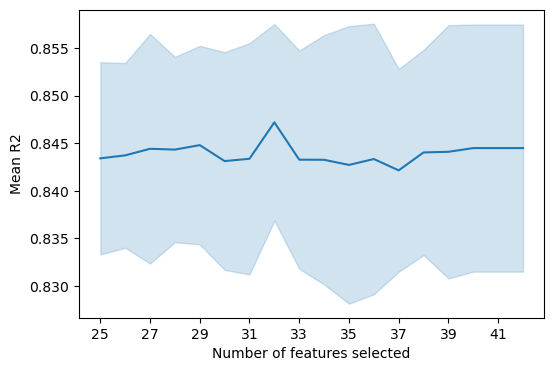

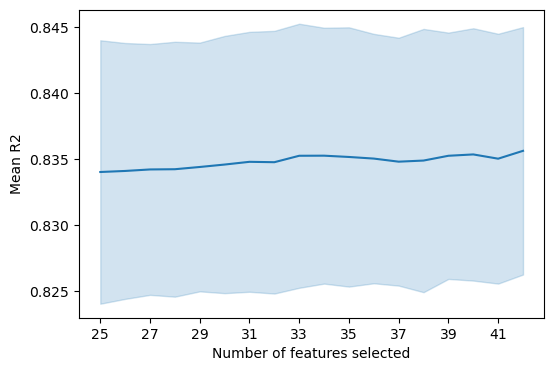

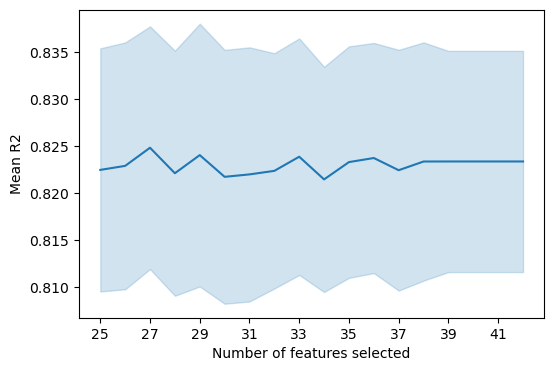

In [39]:



dict_clf = {
    'XGBR': XGBRegressor(n_estimators=200, random_state=int_rdm, n_jobs=-1),
    'RF': RandomForestRegressor(n_estimators=200, random_state=int_rdm, n_jobs=-1),
    'LGBM': LGBMRegressor(n_estimators=200, random_state=int_rdm, n_jobs=-1)
}

for key, clf in dict_clf.items():
    mr.start_rfecv(key, clf, df_sw_data, str_describe_sw, path_part3_sw, path_part3_fig, 'cv', save_file=save_file)

# 12 min

In [ ]:
df_lgbm = pd.read_csv(path_part3_sw + 'sw_rfecv_features_LGBMcv.csv')
df_lgbm['Importance'] = df_lgbm['Importance'] / df_lgbm['Importance'].sum()
df_lgbm.to_csv(path_part3_sw + 'sw_rfecv_features_LGBMcv.csv', index=False)

In [41]:
df_sw_rf_rfecv = pd.read_csv(path_part3_sw + 'sw_rfecv_r2_RFcv.csv')
df_sw_rf_rfecv['model'] = 'RF'
df_sw_gbdt_rfecv = pd.read_csv(path_part3_sw + 'sw_rfecv_r2_XGBRcv.csv')
df_sw_gbdt_rfecv['model'] = 'XGBR'
df_sw_lgbm_rfecv = pd.read_csv(path_part3_sw + 'sw_rfecv_r2_LGBMcv.csv')
df_sw_lgbm_rfecv['model'] = 'LGBM'

df_sw_rfecv = pd.concat([df_sw_rf_rfecv,df_sw_gbdt_rfecv, df_sw_lgbm_rfecv],axis=0)

df_sw_rfecv = df_sw_rfecv.sort_values(by='mean_test_score', ascending=False)
max_index = df_sw_rfecv['mean_test_score'].idxmax()
min_features = df_sw_rfecv.loc[max_index, 'min_features'].tolist()[0]
max_model = df_sw_rfecv.loc[max_index, 'model'].tolist()[0]
max_score = round(df_sw_rfecv.loc[max_index, 'mean_test_score'].tolist()[0],3)
df_sw_rfecv.to_csv(path_part3_sw + 'sw_merge_rfecv.csv',index=False)
print(f'model:{max_model} min_feature:{min_features} score:{max_score}')

model:XGBR min_feature:32 score:0.847


In [ ]:

model_configs = {
        'XGBR': {
            'model_class': XGBRegressor,
            'fixed_params': {'n_jobs': -1, 'verbosity': 0},
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [6, 12],  # XGB 没有 None
                'min_child_weight': [1, 3],
                'gamma': [0, 0.1]
                }
        },
        'LGBM': {
            'model_class': LGBMRegressor,
            'fixed_params': {'verbose': -1, 'n_jobs': -1},
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [6, 12],
                'num_leaves': [127, 255],
                'min_child_samples': [1, 3]
            }
        },
                'RF': {
            'model_class': RandomForestRegressor,
            'fixed_params': {'n_jobs': -1},
            'param_grid': {
                'n_estimators': [200, 300],
                'max_depth': [6, 12],
                'min_samples_split': [2, 6],
                'min_samples_leaf': [1, 3],
            }
        },
    }
    
df_result, df_result_fold = mr.grid_search_param_once_cv(df_sw_data, str_describe_sw, path_part3_sw, model_configs, 'cv', path_part3_temp, list_inv_param_sw, list_treat_value)

df_result.to_csv(path_part3_sw + 'ml_cv_results_once.csv', index=False)
df_result_fold.to_csv(path_part3_sw + 'ml_cv_results_once_fold.csv', index=False)
# 820 min

In [43]:
metrics_config = {
    'R2': {
        'weight': 0.25,
        'higher_is_better': True
    },
    'MAE_orig': {
        'weight': 0.25,
        'higher_is_better': False
    },
    'RMSE': {
        'weight': 0.25,
        'higher_is_better': False
    },
    'MedAE_orig': {
        'weight': 0.25,
        'higher_is_better': False
    }
}  

cv_result = pd.read_csv(path_part3_sw + 'ml_cv_results_once.csv')
new_cv_result, best_result = mr.calc_weighted_score_dict(cv_result, metrics_config)

# 保存
new_cv_result.to_csv(path_part3_sw + 'ml_cv_score.csv', index=False)
best_result.to_csv(path_part3_sw + 'ml_cv_best.csv', index=False)
best_result

,param_idx,fold,gamma,learning_rate,max_depth,min_child_weight,n_estimators,R2,RMSE,MSE,...,MAPE_orig,MedAE_orig,model,min_child_samples,num_leaves,R2_norm,MAE_orig_norm,RMSE_norm,MedAE_orig_norm,score
0,15,4.5,NaN,0.1,12,NaN,300,0.860591,0.367916,0.135619,...,926.159271,0.135493,LGBM,3.0,255.0,1.000000,0.409525,1.000000,1.000000,0.852381
1,7,4.5,0.0,0.1,12,3.0,300,0.849449,0.382431,0.146428,...,866.716294,0.142222,XGBR,NaN,NaN,0.700091,1.000000,0.686418,0.861256,0.811941


### 填补fish

In [9]:
import pandas as pd

lr_data = pd.read_csv(path_part0_match + "lr_full_match_geo_auto_zscore.csv")
lr_data['year'] = (lr_data['year'] - 2000) / (2020 - 2000)
df_lr_final = mr.get_forecast_outcome(df_sw_data, lr_data, path_part3_sw, str_describe_sw, 'cv', int_rdm)
df_lr_final['year'] = df_lr_final['year'] * (2020 - 2000) + 2000
df_lr_final.to_csv(path_part0_match + 'lr_refcv_match.csv', index=False)


LGBM


### water rfecv

In [ ]:
# 处理 water 数据
df_lr_data, list_inv_param_lr, df_lr_transfer = process_pfas_data(
    path_part0_match=path_part0_match,
    filename="lr_refcv_match.csv",
    path_file=path_file,
    selector='bio',
    list_pfas=list_pfas,
    list_treat_value=['log', 'zscore']  # 可以切换归一化类型
)

Box-Cox Lambda: -0.10693903224929828
[ZScore] Mean: -2.027964285321613, Std: 2.2294550511890536
   po_chain        pr       GDP  year     value
0         0 -0.393685  2.773138  0.35  0.535724
1         1 -0.393685  2.773138  0.35  1.248779
2         1 -0.393685  2.773138  0.35  0.872056
3         1 -0.393685  2.773138  0.35  1.400200
4         0 -0.393685  2.773138  0.35  0.239359
(19025, 46)


XGBR Optimal number of features: 41
LGBM Optimal number of features: 37
RF Optimal number of features: 34


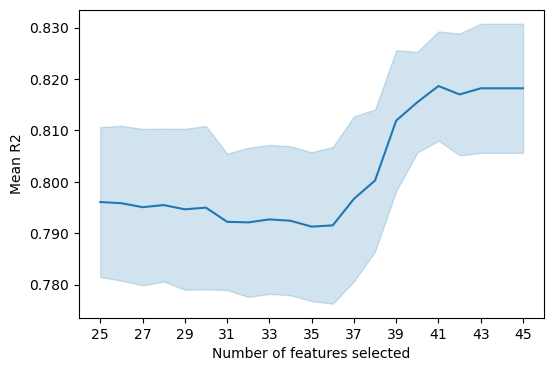

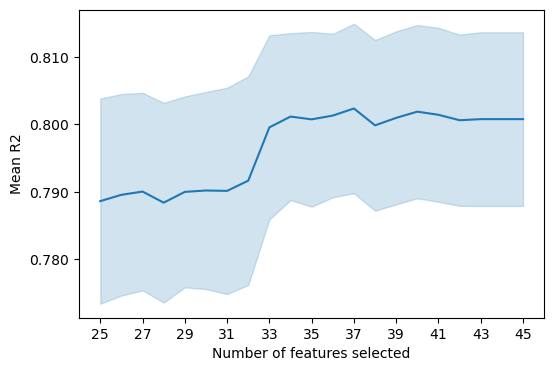

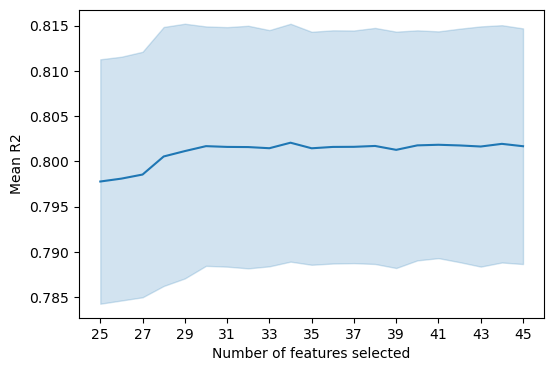

In [22]:


dict_clf = {
    'XGBR': XGBRegressor(n_estimators=200, random_state=int_rdm, n_jobs=-1),
    'LGBM': LGBMRegressor(n_estimators=200, random_state=int_rdm, n_jobs=-1),
    'RF': RandomForestRegressor(n_estimators=200, random_state=int_rdm, n_jobs=-1),
}

for key, clf in dict_clf.items():
    mr.start_rfecv(key, clf, df_lr_data, str_describe_lr, path_part3_lr, path_part3_fig, 'cv')


In [ ]:
df_lgbm = pd.read_csv(path_part3_lr + 'lr_rfecv_features_LGBMcv.csv')
df_lgbm['Importance'] = df_lgbm['Importance'] / df_lgbm['Importance'].sum()
df_lgbm.to_csv(path_part3_lr + 'lr_rfecv_features_LGBMcv.csv', index=False)

In [24]:
import pandas as pd
df_lr_rf_rfecv = pd.read_csv(path_part3_lr + 'lr_rfecv_r2_RFcv.csv')
df_lr_rf_rfecv['model'] = 'RF'
df_lr_gbdt_rfecv = pd.read_csv(path_part3_lr + 'lr_rfecv_r2_XGBRcv.csv')
df_lr_gbdt_rfecv['model'] = 'XGBR'
df_lr_lgbm_rfecv = pd.read_csv(path_part3_lr + 'lr_rfecv_r2_LGBMcv.csv')
df_lr_lgbm_rfecv['model'] = 'LGBM'


df_lr_rfecv = pd.concat([df_lr_rf_rfecv, df_lr_gbdt_rfecv, df_lr_lgbm_rfecv],axis=0)

df_lr_rfecv = df_lr_rfecv.sort_values(by='mean_test_score', ascending=False)
print(df_lr_rfecv.head())
max_index = df_lr_rfecv['mean_test_score'].idxmax()
min_features = df_lr_rfecv.loc[max_index, 'min_features'].tolist()[0]
max_model = df_lr_rfecv.loc[max_index, 'model'].tolist()[0]
max_score = round(df_lr_rfecv.loc[max_index, 'mean_test_score'].tolist()[0],3)
df_lr_rfecv.to_csv(path_part3_lr + 'lr_merge_rfecv.csv',index=False)
print(f'model:{max_model} min_feature:{min_features} score:{max_score}')

   min_features  mean_test_score  std_test_score model
0            41         0.818643        0.010621  XGBR
1            45         0.818194        0.012567  XGBR
3            43         0.818194        0.012567  XGBR
2            44         0.818194        0.012567  XGBR
4            42         0.817005        0.011843  XGBR
model:XGBR min_feature:41 score:0.819


In [ ]:
model_configs = {
        'XGBR': {
            'model_class': XGBRegressor,
            'fixed_params': {'n_jobs': -1, 'verbosity': 0},
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [6, 12],  # XGB 没有 None
                'min_child_weight': [1, 3],
                'gamma': [0, 0.1]
                }
        },
        'RF': {
            'model_class': RandomForestRegressor,
            'fixed_params': {'n_jobs': -1},
            'param_grid': {
                'n_estimators': [200, 300],
                'max_depth': [6, 12],
                'min_samples_split': [2, 6],
                'min_samples_leaf': [1, 3],
            }
        },
        'LGBM': {
            'model_class': LGBMRegressor,
            'fixed_params': {'verbose': -1, 'n_jobs': -1},
            'param_grid': {
                'n_estimators': [200, 300],
                'learning_rate': [0.1],
                'max_depth': [6, 12],
                'num_leaves': [127, 255],
                'min_child_samples': [1, 3]
            }
        }
    }

df_result, df_result_fold = mr.grid_search_param_once_cv(df_lr_data, str_describe_lr, path_part3_lr, model_configs, 'cv', path_part3_temp, list_inv_param_lr, list_treat_value)

df_result.to_csv(path_part3_lr + 'ml_cv_results_once.csv', index=False)
df_result_fold.to_csv(path_part3_lr + 'ml_cv_results_once_fold.csv', index=False)
# 1100 min

In [26]:
metrics_config = {
    'R2': {
        'weight': 0.25,
        'higher_is_better': True
    },
    'MAE_orig': {
        'weight': 0.25,
        'higher_is_better': False
    },
    'RMSE': {
        'weight': 0.25,
        'higher_is_better': False
    },
    'MedAE_orig': {
        'weight': 0.25,
        'higher_is_better': False
    }
}

cv_result = pd.read_csv(path_part3_lr + 'ml_cv_results_once.csv')
new_cv_result, best_result = mr.calc_weighted_score_dict(cv_result, metrics_config)

# 保存
new_cv_result.to_csv(path_part3_lr + 'ml_cv_score.csv', index=False)
best_result.to_csv(path_part3_lr + 'ml_cv_best.csv', index=False)
best_result

,param_idx,fold,gamma,learning_rate,max_depth,min_child_weight,n_estimators,R2,RMSE,MSE,...,MAPE_orig,MedAE_orig,model,min_child_samples,num_leaves,R2_norm,MAE_orig_norm,RMSE_norm,MedAE_orig_norm,score
0,8,4.5,NaN,0.1,12,NaN,200,0.825201,0.431058,0.186148,...,89.632488,0.039576,LGBM,1.0,127.0,0.861730,0.866894,0.857103,0.864828,0.862638
1,6,4.5,0.0,0.1,12,3.0,200,0.816867,0.441251,0.195039,...,111.835114,0.038401,XGBR,NaN,NaN,0.527895,0.968322,0.517748,0.980839,0.748701


### 迁移验证

In [ ]:


print(df_sw_transfer['posname'].unique().tolist())
print('train shape:', df_sw_data.shape)
print('tranfer shape:', df_sw_transfer.shape)

best_params_sw = pd.read_csv(path_part3_sw + 'ml_cv_best.csv')
best_params_sw = best_params_sw.sort_values(by='score', ascending=False)
# 获取best_params中score最高的model列数据
best_model_sw = best_params_sw.iloc[0]['model']
print(best_model_sw)

selected_features_sw = pd.read_csv(path_part3_sw + str_describe_sw + "_rfecv_features_" + best_model_sw + "cv.csv")
selected_features_sw = selected_features_sw[selected_features_sw["Rank"] == 1]["Feature"].values


model_sw = mg.train_forecast_model(df_sw_data, best_params_sw, selected_features_sw, best_model_sw, int_rdm)
X_transfer = df_sw_transfer[selected_features_sw].copy()
y_transfer_true = df_sw_transfer['value'].copy()  # 转换空间真实值
y_transfer_pred = model_sw.predict(X_transfer)
df_forecast_data = pd.DataFrame({
    'y_true': y_transfer_true,
    'y_pred': y_transfer_pred
})
# 对真实值和预测值进行逆转换到原始空间
df_forecast_data['y_true_orig'] = mg.custom_inv(df_forecast_data['y_true'], list_inv_param_sw, list_treat_value)
df_forecast_data['y_pred_orig'] = mg.custom_inv(df_forecast_data['y_pred'], list_inv_param_sw, list_treat_value)
print(df_forecast_data.head())
df_forecast_data.to_csv(path_part3_temp + 'sw_TF.csv', index=False)


['EtFOSA', '6:2 Cl-PFESA', '6:2 FTSA', '6:2 diPAP', '6:2/8:2 diPAP', '6:8 PFPIA', 'EtFOSAA', 'EtFOSE', 'FOSAA', 'MeFOSA', 'MeFOSAA', 'PFECHS', 'PFHxDA', '4:2 FTSA', '8:2 FTSA', 'PFODA', 'PFPeDA', '8:2 diPAP', '10:2 FTSA']
train shape: (13256, 43)
tranfer shape: (752, 46)
LGBM
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': 12, 'min_child_samples': 3, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 300, 'n_jobs': 1, 'num_leaves': 127, 'objective': None, 'random_state': 202509, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'silent': 'warn', 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 1}
      y_true    y_pred  y_true_orig  y_pred_orig
112 -1.04707 -0.670814       0.0125     0.039405
126 -1.04707 -0.964800       0.0125     0.016082
168 -1.04707 -0.678627       0.0125     0.038481
184 -1.04707 -0.816035       0.0125     0.025331
248 -1.04707 -0.848323       0.0125     0.022

In [ ]:


print('train shape:', df_lr_data.shape)
print('tranfer shape:', df_lr_transfer.shape)

best_params_lr = pd.read_csv(path_part3_lr + 'ml_cv_best.csv')
best_params_lr = best_params_lr.sort_values(by='score', ascending=False)
best_model_lr = best_params_lr.iloc[0]['model']
print(best_model_lr)

selected_features_lr = pd.read_csv(path_part3_lr + str_describe_lr + "_rfecv_features_" + best_model_lr + "cv.csv")
selected_features_lr = selected_features_lr[selected_features_lr["Rank"] == 1]["Feature"].values

model_lr = mg.train_forecast_model(df_lr_data, best_params_lr, selected_features_lr, best_model_lr, int_rdm)
X_transfer = df_lr_transfer[selected_features_lr].copy()
y_transfer_true = df_lr_transfer['value'].copy()  # 转换空间真实值
y_transfer_pred = model_lr.predict(X_transfer)
df_forecast_data = pd.DataFrame({
    'y_true': y_transfer_true,
    'y_pred': y_transfer_pred
})
# 对真实值和预测值进行 Box-Cox 逆转换到原始空间
df_forecast_data['y_true_orig'] = mg.custom_inv(df_forecast_data['y_true'], list_inv_param_lr, ['log', 'zscore'])
df_forecast_data['y_pred_orig'] = mg.custom_inv(df_forecast_data['y_pred'], list_inv_param_lr, ['log', 'zscore'])
print(df_forecast_data.head())
df_forecast_data.to_csv(path_part3_temp + 'lr_TF.csv', index=False)


train shape: (19025, 46)
tranfer shape: (2525, 49)
LGBM
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': 12, 'min_child_samples': 1, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 300, 'n_jobs': 1, 'num_leaves': 255, 'objective': None, 'random_state': 202509, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'silent': 'warn', 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 1}
       y_true    y_pred  y_true_orig  y_pred_orig
375 -1.759483 -1.432363         0.01     0.015788
385 -1.759483 -1.099714         0.01     0.025731
395 -1.759483 -1.493612         0.01     0.014469
405 -1.759483 -1.658118         0.01     0.011493
415 -1.759483 -1.877721         0.01     0.008524


### fish re

In [ ]:
list_pfas_lc = ['PFOA', 'PFNA', 'PFDA', 'PFUnDA','PFDoDA','PFTrDA', 'PFTeDA', 'PFHxS', 'PFOS', 'FOSA']
list_pfas_sc = ['PFBA', 'PFPeA', 'PFHxA', 'PFHpA','PFBS','HFPO-DA']

list_pfas_16 = ['PFOA', 'PFNA', 'PFDA', 'PFUnDA','PFDoDA','PFTrDA', 'PFTeDA', 'PFHxS', 'PFOS', 'FOSA',
                'PFBA', 'PFPeA', 'PFHxA', 'PFHpA','PFBS','HFPO-DA']


list_pfas_20 = ['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 
             'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 
             'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']

In [ ]:
import os
import numpy as np
import pandas as pd

from scipy.stats import boxcox
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error
from lightgbm import LGBMRegressor

seed = 20260300
str_describe_lr = 'lr'
save_file = True

save_dir = r'E:/wyy/code_project/running_outcome/final_data/SPDB/part1_describe/shap1/data/'
os.makedirs(save_dir, exist_ok=True)

# =========================
# list_pfas_20 = ['PFBS', 'PFDA', 'PFHpA', 'PFHxA', 'PFHxS', 'PFNA', 'PFOA', 
#                 'PFOS', 'FOSA', 'PFDoDA', 'PFTeDA', 'PFUnDA', 'PFTrDA', 
#                 'HFPO-DA', 'PFBA', 'PFDS', 'PFHpS', 'PFNS', 'PFPeA', 'PFPeS']
# group_dict = {f'list{i+1}': [list_pfas_20[i]] for i in range(20)}

# 切换group_dict
# 上面是单个建模，下面是分组建模

group_dict = {
    'list1': ['PFOA'],
    'list2': ['PFTeDA'],
    'list3': ['PFPeA', 'PFHxA', 'PFHpA'],
    'list4': ['PFUnDA', 'PFTrDA', 'PFDoDA'],
    'list5': ['PFDS'],
    'list6': ['PFBA'],
    'list7': ['PFHxS'],
    'list8': ['PFBA'],
    'list9': ['PFHxS'],
    'list10': ['PFBS', 'PFNS'],
    'list11': ['4:2 FTSA', '6:2 FTSA', 'HFPO-DA'],
    'list12': ['PFDA', 'PFNA'],
    'list13': ['PFOS'],
    'list14': ['FOSA', 'EtFOSAA', 'EtFOSA', 'MeFOSA', 'MeFOSAA']
    }


all_group_pfas = []
for group_pfas in group_dict.values():
    all_group_pfas.extend(group_pfas)
all_group_pfas = list(set(all_group_pfas))



def process_pfas_data(path_part0_match, filename, path_file, selector, list_pfas, list_treat_value=['log', 'minmax']):
    """
    通用 PFAS 数据处理函数：Box-Cox + 归一化（MinMax 或 ZScore）

    参数：
        path_part0_match: 数据路径前缀
        filename: CSV 文件名
        path_file: mf.select_data 的文件路径参数
        selector: mf.select_data 的第二个参数 ('w' 或 'bio')
        list_pfas: 需要选择的 posname 列表
        list_treat_value: 处理方法 ['log', 'minmax'] 或 ['log', 'zscore']

    返回：
        df_train: 训练集数据（去掉指定列）
        df_transfer: transfer 数据（非 list_pfas 部分）
        list_inv_parm: 反处理参数 [min,max,lambda] 或 [mean,std,lambda]
    """

    df_raw = pd.read_csv(path_part0_match + filename)
    df_data_raw = mf.select_data(df_raw, path_file, selector)
    df_data_raw = df_data_raw[df_data_raw['posname'].isin(list_pfas)].copy()
    # Box-Cox 转换
    if (df_data_raw['value'] <= 0).any():
        raise ValueError("Box-Cox 变换要求 value 全部大于 0，请先检查数据。")

    df_data_raw['value'], lam = boxcox(df_data_raw['value'])
    print(f'Box-Cox Lambda: {lam}')
    # 归一化方法选择
    if 'minmax' in list_treat_value:
        max_val = df_data_raw['value'].max()
        min_val = df_data_raw['value'].min()
        print(f"[MinMax] Max: {max_val}, Min: {min_val}")
        df_data_raw['value'] = (df_data_raw['value'] - min_val) / (max_val - min_val)
        list_inv_parm = [min_val, max_val, lam]

    elif 'zscore' in list_treat_value:
        mean_val = df_data_raw['value'].mean()
        std_val = df_data_raw['value'].std()
        print(f"[ZScore] Mean: {mean_val}, Std: {std_val}")
        df_data_raw['value'] = (df_data_raw['value'] - mean_val) / std_val
        list_inv_parm = [mean_val, std_val, lam]

    else:
        raise ValueError("list_treat_value 必须包含 'minmax' 或 'zscore'")

    columns_to_drop = ['lon_grid', 'lat_grid']
    df_train = df_data_raw.drop(columns=columns_to_drop, errors='ignore').copy()

    if 'year' in df_train.columns:
        df_train['year'] = (df_train['year'] - 2000) / (2020 - 2000)

    print(df_train[['po_chain', 'pr', 'GDP', 'year', 'value']].head())
    print(df_train.shape)
    df_transfer = pd.DataFrame()

    return df_train, list_inv_parm, df_transfer



df_lr_data, list_inv_param_lr, _ = process_pfas_data(
    path_part0_match=path_part0_match,
    filename="lr_refcv_match.csv",
    path_file=path_file,
    selector='bio',
    list_pfas=all_group_pfas,
    list_treat_value=['log', 'zscore']
)

best_params = pd.read_csv(path_part3_lr + 'ml_cv_best.csv')
best_params = best_params.sort_values(by='score', ascending=False)
best_model = best_params.iloc[0]['model']
print("Best model:", best_model)

selected_features_all = pd.read_csv(
    path_part3_lr + str_describe_lr + "_rfecv_features_" + best_model + "cv.csv"
)
selected_features_all = selected_features_all[selected_features_all["Rank"] == 1]["Feature"].tolist()

feature_remove = [
    'po_carbon', 'solubility', 'density', 'log_pKa', 'log_Koil_w',
    'po_m_w', 'log_D5_5', 'po_chain', 'log_Px'
]

print("Original selected features:", selected_features_all)


model_params = best_params[best_params["model"] == best_model].iloc[0]

if pd.isna(model_params["max_depth"]) or str(model_params["max_depth"]).lower() == 'none':
    param_max_depth = None
else:
    param_max_depth = int(float(model_params["max_depth"]))

target_col = 'value'
pfas_col = 'posname'


list_metric_rows = []
list_pred_rows = []

for group_name, group_pfas in group_dict.items():
    print(f"\n========== Group: {group_name} ==========")
    print("PFAS in group:", group_pfas)

    df_sub = df_lr_data[df_lr_data[pfas_col].isin(group_pfas)].copy()

    if len(group_pfas) == 1:
        selected_features = [feat for feat in selected_features_all if feat not in feature_remove]
        print(f"{group_name} only has one PFAS -> remove feature_remove")
    else:
        selected_features = selected_features_all.copy()
        print(f"{group_name} has multiple PFAS -> keep all selected features")

    print("Selected features for this group:", selected_features)

    missing_feats = [col for col in selected_features if col not in df_sub.columns]
    if len(missing_feats) > 0:
        raise ValueError(f"{group_name} 中以下特征不存在: {missing_feats}")

    if target_col not in df_sub.columns:
        raise ValueError(f"{group_name} 中未找到目标列: {target_col}")

    if pfas_col not in df_sub.columns:
        raise ValueError(f"{group_name} 中未找到 PFAS 标识列: {pfas_col}")

    df_sub = df_sub.dropna(subset=selected_features + [target_col])

    n_samples = len(df_sub)
    print(f"Sample size: {n_samples}")

    if n_samples < 10:
        print(f"Skip {group_name}: 样本数不足10，无法做10折CV")
        list_metric_rows.append({
            'group': group_name,
            'PFAS_list': ','.join(group_pfas),
            'fold': 'all',
            'n_samples': n_samples,
            'R2': np.nan,
            'RMSE': np.nan,
            'note': 'insufficient samples for 10-fold CV'
        })
        continue

    X = df_sub[selected_features].copy()
    y = df_sub[target_col].copy()

    kf = KFold(n_splits=10, shuffle=True, random_state=seed)

    fold_r2_list = []
    fold_rmse_list = []

    for fold_id, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = LGBMRegressor(
            max_depth=param_max_depth,
            learning_rate=model_params["learning_rate"],
            min_child_samples=int(model_params["min_child_samples"]),
            num_leaves=int(model_params["num_leaves"]),
            n_estimators=int(model_params["n_estimators"]),
            random_state=seed,
            subsample=0.8,
            subsample_freq=1,
            n_jobs=12
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_r2 = r2_score(y_test, y_pred)
        fold_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        fold_r2_list.append(fold_r2)
        fold_rmse_list.append(fold_rmse)

        # 保存每折指标
        list_metric_rows.append({
            'group': group_name,
            'PFAS_list': ','.join(group_pfas),
            'fold': fold_id,
            'n_samples': n_samples,
            'train_size': len(train_idx),
            'test_size': len(test_idx),
            'R2': fold_r2,
            'RMSE': fold_rmse,
            'note': ''
        })
        df_pred_fold = df_sub.iloc[test_idx].copy()
        df_pred_fold['group'] = group_name
        df_pred_fold['fold'] = fold_id
        df_pred_fold['y_true'] = y_test.values
        df_pred_fold['y_pred'] = y_pred
        list_pred_rows.append(df_pred_fold)

    list_metric_rows.append({
        'group': group_name,
        'PFAS_list': ','.join(group_pfas),
        'fold': 'mean',
        'n_samples': n_samples,
        'train_size': np.nan,
        'test_size': np.nan,
        'R2': np.mean(fold_r2_list),
        'RMSE': np.mean(fold_rmse_list),
        'note': '10-fold mean'
    })

    print(f"{group_name} mean R2   : {np.mean(fold_r2_list):.4f}")
    print(f"{group_name} mean RMSE : {np.mean(fold_rmse_list):.4f}")


def inverse_boxcox(y_bc, lam):
    y_bc = np.asarray(y_bc, dtype=float)
    if lam == 0:
        return np.exp(y_bc)
    else:
        val = lam * y_bc + 1
        if np.any(val <= 0):
            raise ValueError("Box-Cox 逆变换时出现 lam * y + 1 <= 0，无法还原。")
        return np.power(val, 1 / lam)

df_all_metrics = pd.DataFrame(list_metric_rows)

if len(list_pred_rows) > 0:
    df_all_pred = pd.concat(list_pred_rows, axis=0, ignore_index=True)
else:
    df_all_pred = pd.DataFrame()


if not df_all_pred.empty:
    mean_val, std_val, lam = list_inv_param_lr

    # zscore 逆变换 -> Box-Cox 尺度
    df_all_pred['y_true_bc'] = df_all_pred['y_true'] * std_val + mean_val
    df_all_pred['y_pred_bc'] = df_all_pred['y_pred'] * std_val + mean_val

    # Box-Cox 逆变换 -> 原始尺度
    df_all_pred['y_true_raw'] = inverse_boxcox(df_all_pred['y_true_bc'], lam)
    df_all_pred['y_pred_raw'] = inverse_boxcox(df_all_pred['y_pred_bc'], lam)

if not df_all_pred.empty:
    raw_metric_rows = []

    for (group_name, fold_id), df_fold in df_all_pred.groupby(['group', 'fold']):
        raw_metric_rows.append({
            'group': group_name,
            'fold': str(fold_id),
            'R2_raw': r2_score(df_fold['y_true_raw'], df_fold['y_pred_raw']),
            'RMSE_raw': np.sqrt(mean_squared_error(df_fold['y_true_raw'], df_fold['y_pred_raw'])),
            'MAE_raw': mean_absolute_error(df_fold['y_true_raw'], df_fold['y_pred_raw']),
            'MedAE_raw': median_absolute_error(df_fold['y_true_raw'], df_fold['y_pred_raw'])
        })

    df_raw_fold_metrics = pd.DataFrame(raw_metric_rows)

    df_raw_mean_metrics = (
        df_raw_fold_metrics
        .groupby('group', as_index=False)[['R2_raw', 'RMSE_raw', 'MAE_raw', 'MedAE_raw']]
        .mean()
    )
    df_raw_mean_metrics['fold'] = 'mean'

    # 合并 每折 + 均值
    df_raw_metrics_all = pd.concat(
        [df_raw_fold_metrics, df_raw_mean_metrics],
        axis=0,
        ignore_index=True
    )

    df_all_metrics['fold'] = df_all_metrics['fold'].astype(str)
    df_raw_metrics_all['fold'] = df_raw_metrics_all['fold'].astype(str)

    df_all_metrics = df_all_metrics.merge(
        df_raw_metrics_all,
        on=['group', 'fold'],
        how='left'
    )
else:
    df_all_metrics['R2_raw'] = np.nan
    df_all_metrics['RMSE_raw'] = np.nan
    df_all_metrics['MAE_raw'] = np.nan
    df_all_metrics['MedAE_raw'] = np.nan

df_metric_mean = df_all_metrics[df_all_metrics['fold'] == 'mean'].copy()
df_metric_mean = df_metric_mean.sort_values(by='R2_raw', ascending=False)


if save_file:
    df_all_metrics.to_csv(
        os.path.join(save_dir, 'group_10fold_cv_metrics_all.csv'),
        index=False,
        encoding='utf-8-sig'
    )
    df_metric_mean.to_csv(
        os.path.join(save_dir, 'group_10fold_cv_metrics_mean.csv'),
        index=False,
        encoding='utf-8-sig'
    )
    df_all_pred.to_csv(
        os.path.join(save_dir, 'group_10fold_cv_predictions.csv'),
        index=False,
        encoding='utf-8-sig'
    )

    print(save_dir)

print("\n===== Done =====")
print("df_all_metrics shape:", df_all_metrics.shape)
print("df_metric_mean shape:", df_metric_mean.shape)
print("df_all_pred shape:", df_all_pred.shape)

In [ ]:
import os
import numpy as np
import pandas as pd

file_path = r"E:\wyy\code_project\running_outcome\final_data\SPDB\part1_describe\shap1\data\group_10fold_cv_predictions.csv"
df = pd.read_csv(file_path)

df = df[['group', 'fold', 'y_true_raw', 'y_pred_raw']].copy()

valid_mask = (
    df['y_true_raw'].notna() &
    df['y_pred_raw'].notna() &
    (df['y_true_raw'] > 0) &
    (df['y_pred_raw'] > 0)
)
df_valid = df[valid_mask].copy()


def calc_fold_stats(group_df):
    x = group_df['y_true_raw'].to_numpy()
    y = group_df['y_pred_raw'].to_numpy()

    ratio = y / x
    within_2fold = (ratio >= 0.5) & (ratio <= 2.0)
    within_10fold = (ratio >= 0.1) & (ratio <= 10.0)

    n = len(ratio)
    n_2fold = np.sum(within_2fold)
    n_10fold = np.sum(within_10fold)

    return pd.Series({
        'n_samples': n,
        'n_within_2fold': int(n_2fold),
        'pct_within_2fold': n_2fold / n * 100 if n > 0 else np.nan,
        'n_within_10fold': int(n_10fold),
        'pct_within_10fold': n_10fold / n * 100 if n > 0 else np.nan,
    })

result_group_fold_df = (
    df_valid
    .groupby(['group', 'fold'])
    .apply(calc_fold_stats)
    .reset_index()
)

result_group_df = (
    df_valid
    .groupby(['group'])
    .apply(calc_fold_stats)
    .reset_index()
)

output_dir = os.path.dirname(file_path)

output_group_fold_path = os.path.join(output_dir, "group_fold_2fold_10fold_stats.csv")
output_group_path = os.path.join(output_dir, "group_2fold_10fold_stats.csv")

result_group_fold_df.to_csv(output_group_fold_path, index=False, encoding='utf-8-sig')
result_group_df.to_csv(output_group_path, index=False, encoding='utf-8-sig')

print(output_group_fold_path)
print(output_group_path)
print(result_group_fold_df.head())
print(result_group_df.head())